In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/keerti8/final-df/final_df.csv
/kaggle/input/datasets/keerti8/finaldti/processed_images/007_S_4488_2.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/003_S_4441_0.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/073_S_10352_2.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/033_S_10229_2.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/389_S_10115_2.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/052_S_4944_1.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/021_S_6896_2.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/003_S_4136_0.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/127_S_4500_1.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/094_S_4560_2.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/021_S_4718_0.png
/kaggle/input/datasets/keerti8/finaldti/processed_images/029_S_4652_0.png
/kaggle/input/datasets/keerti8/finaldti/processed_images

In [2]:
base_path = "/kaggle/input/datasets/keerti8/finaldti/processed_images/"

In [3]:
import os

for root, dirs, files in os.walk(base_path):
    print("Folder:", root)
    print("Number of files:", len(files))
    print("-"*30)

Folder: /kaggle/input/datasets/keerti8/finaldti/processed_images/
Number of files: 573
------------------------------


In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/keerti8/final-df/final_df.csv")
print(df.head())

      RID VISCODE  DX        AGE  APOE4 PTGENDER Image Data ID
0    69.0     m12   0  72.933607      0     Male     I11183687
1   769.0      bl   1  62.214921      0     Male        I23428
2   200.0     m12   1  61.497604      0     Male     I11482389
3  2245.0     m06   1  57.013005      2   Female       I239288
4  2234.0     m06   1  63.668720      0   Female       I240989


In [5]:
apoe_map = dict(zip(df['RID'], df['APOE4']))

In [6]:
print(df.columns)

Index(['RID', 'VISCODE', 'DX', 'AGE', 'APOE4', 'PTGENDER', 'Image Data ID'], dtype='object')


In [7]:
label_map = dict(zip(df['RID'], df['DX']))

In [8]:
import cv2
import os

images = []
labels = []
apoe_features = []
rids = []

seen_rids = set()

base_path = "/kaggle/input/datasets/keerti8/finaldti/processed_images/"

for root, dirs, files in os.walk(base_path):
    for file in files:

        if not file.endswith(".png"):
            continue

        parts = file.replace(".png","").split("_")

        if len(parts) < 3:
            continue

        try:
            rid = int(parts[2])
        except:
            continue

        if rid in seen_rids:
            continue

        seen_rids.add(rid)

        if rid in label_map and rid in apoe_map:
            img = cv2.imread(os.path.join(root, file), 0)
            img = cv2.resize(img, (128,128))
            img = img / 255.0

            images.append(img)
            labels.append(label_map[rid])
            apoe_features.append(apoe_map[rid])
            rids.append(rid)

print("Total samples:", len(images))



Total samples: 86


In [9]:
import numpy as np

X = np.array(images)
y = np.array(labels)
X_apoe = np.array(apoe_features)
rids = np.array(rids)

import numpy as np

X_apoe = np.array(apoe_features)

X_apoe = X_apoe.reshape(-1, 1)

X_apoe = (X_apoe - np.mean(X_apoe)) / np.std(X_apoe)

print("APOE shape:", X_apoe.shape)
print("X:", X.shape)
print("y:", y.shape)

APOE shape: (86, 1)
X: (86, 128, 128)
y: (86,)


In [10]:
print(len(images), len(labels), len(apoe_features))

86 86 86


In [11]:
print("Total images in folder:", len(os.listdir(base_path)))
print("Images used:", len(images))

Total images in folder: 573
Images used: 86


In [12]:
print("Unique RIDs in CSV:", len(set(df['RID'])))

Unique RIDs in CSV: 86


In [13]:
image_rids = set(int(f.split("_")[2]) for f in os.listdir(base_path))
print("Unique RIDs in images:", len(image_rids))

Unique RIDs in images: 191


In [14]:
print("Common RIDs:", len(image_rids.intersection(set(df['RID']))))

Common RIDs: 86


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Encoded labels:", set(y))

Encoded labels: {np.int64(0), np.int64(1), np.int64(2)}


In [16]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(X, y, groups=rids))

X_img_train = X[train_idx]
X_img_test  = X[test_idx]

X_apoe_train = X_apoe[train_idx]
X_apoe_test  = X_apoe[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

In [17]:
print("Train:", np.bincount(y_train))
print("Test:", np.bincount(y_test))

Train: [30 11 28]
Test: [10  1  6]


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1],
    2: class_weights_array[2]
}

# Stabilize weight
for k in class_weights:
    class_weights[k] = min(class_weights[k], 2.0)  # cap extreme values

class_weights[1] *= 1.2   

print("Final Class weights:", class_weights)

Final Class weights: {0: np.float64(0.7666666666666667), 1: 2.4, 2: np.float64(0.8214285714285714)}


In [19]:
from tensorflow.keras import layers, Model, Input

# IMAGE BRANCH
img_input = Input(shape=(128,128,1))

x = layers.Conv2D(16, (3,3), activation='relu')(img_input)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)  
x = layers.Dense(32, activation='relu')(x)

# APOE / CLINICAL BRANCH
apoe_input = Input(shape=(1,))

y_branch = layers.Dense(2, activation='relu')(apoe_input)

y_branch = layers.Lambda(lambda x: x * 0.3)(y_branch)

# FUSION
combined = layers.concatenate([x, y_branch])   

z = layers.Dense(16, activation='relu')(combined)
z = layers.Dropout(0.2)(z)

output = layers.Dense(3, activation='softmax')(z)

model = Model(inputs=[img_input, apoe_input], outputs=output)

2026-04-20 05:22:46.518099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776662566.750942      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776662566.823399      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776662567.393594      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776662567.393639      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776662567.393642      55 computation_placer.cc:177] computation placer alr

In [20]:
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
        y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)
        
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        
        return K.sum(weight * cross_entropy, axis=1)
    return loss

In [21]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    [X_img_train, X_apoe_train],   
    y_train,
    validation_data=([X_img_test, X_apoe_test], y_test),
    epochs=30,                    
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.3105 - loss: 1.1807 - val_accuracy: 0.4118 - val_loss: 1.0949 - learning_rate: 5.0000e-04
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.3295 - loss: 1.1489 - val_accuracy: 0.4706 - val_loss: 1.0955 - learning_rate: 5.0000e-04
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4012 - loss: 1.2071 - val_accuracy: 0.4706 - val_loss: 1.0951 - learning_rate: 5.0000e-04
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.2441 - loss: 1.1800 - val_accuracy: 0.4706 - val_loss: 1.0960 - learning_rate: 5.0000e-04
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3874 - loss: 1.1550 - val_accuracy: 0.4706 - val_loss: 1.0948 - learning_rate: 2.5000e-04
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3694 - loss: 1.1679 - val_accuracy: 0.4706 - val_loss: 1.0936 - learning_rate: 2.5000e-04
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3864 - loss: 1.171

In [23]:
loss, acc = model.evaluate(
    [X_img_test, X_apoe_test],
    y_test
)

print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5882 - loss: 1.0901
Test Accuracy: 0.5882353186607361


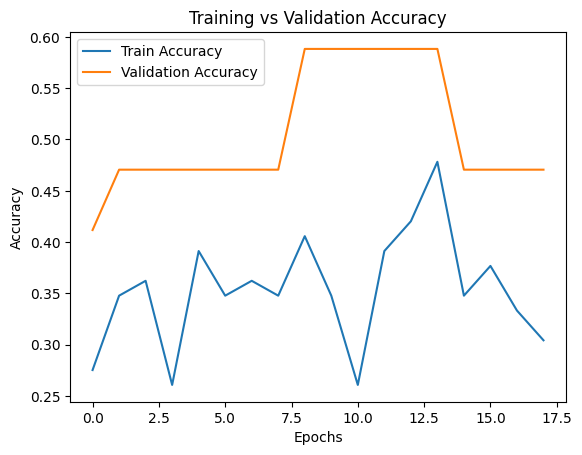

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

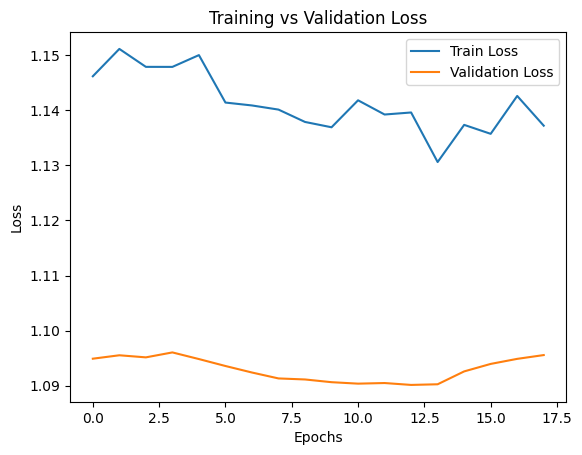

In [25]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


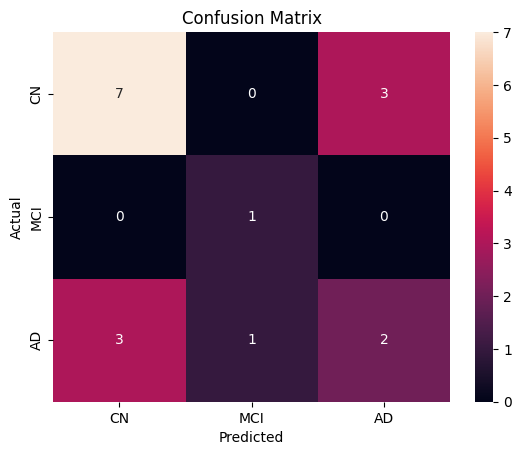


Classification Report:

              precision    recall  f1-score   support

          CN       0.70      0.70      0.70        10
         MCI       0.50      1.00      0.67         1
          AD       0.40      0.33      0.36         6

    accuracy                           0.59        17
   macro avg       0.53      0.68      0.58        17
weighted avg       0.58      0.59      0.58        17



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_probs = model.predict([X_img_test, X_apoe_test])

y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['CN','MCI','AD'],
    yticklabels=['CN','MCI','AD']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['CN','MCI','AD']))

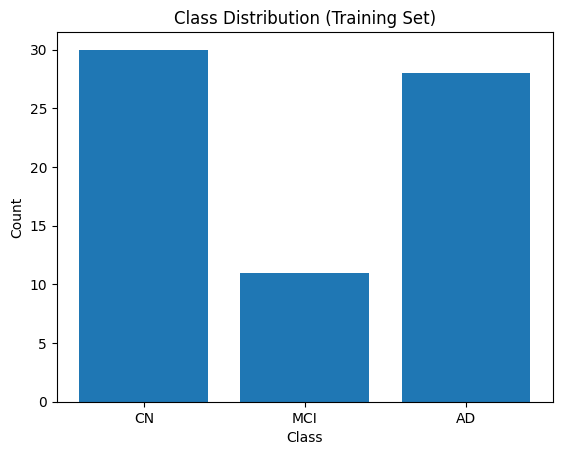

In [27]:
import numpy as np
import matplotlib.pyplot as plt

classes, counts = np.unique(y_train, return_counts=True)

plt.figure()
plt.bar(['CN','MCI','AD'], counts)

plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

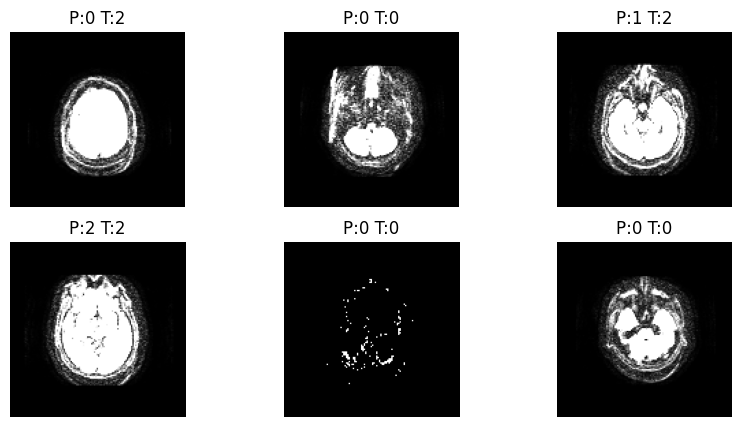

In [28]:
import random

plt.figure(figsize=(10,5))

for i in range(6):
    idx = random.randint(0, len(X_img_test)-1)

    plt.subplot(2,3,i+1)
    plt.imshow(X_img_test[idx].reshape(128,128), cmap='gray')

    pred = y_pred[idx]
    true = y_test[idx]

    plt.title(f"P:{pred} T:{true}")
    plt.axis('off')

plt.show()